In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import truncnorm
from scipy.optimize import minimize
from scipy.stats import norm
import xlwings as xw
import statsmodels.api as sm
import math
from tqdm import tqdm
from scipy.stats import beta as beta_dist, poisson
import matplotlib.ticker as mticker
from scipy import stats

             Preco
Data              
1996-09-02  123.09
1996-09-03  119.68
1996-09-04  119.39
1996-09-05  118.42
1996-09-06  118.09
              Preco
Data               
2025-10-13  2219.96
2025-10-14  2301.24
2025-10-15  2314.21
2025-10-16  2269.67
2025-10-17  2262.88


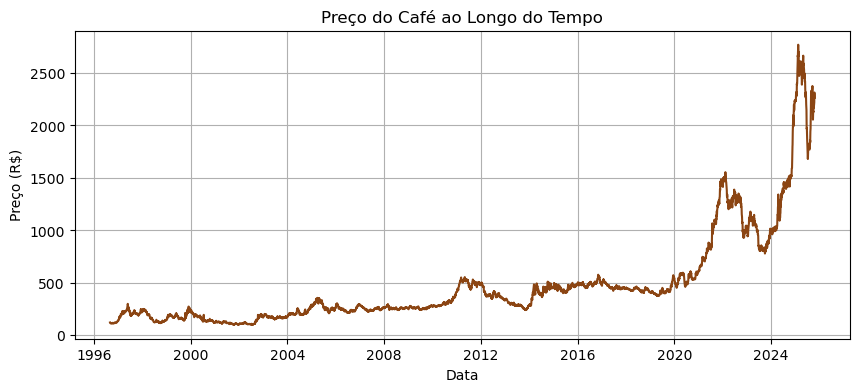

=== Estatísticas Descritivas ===
count    7255.000000
mean      474.544509
std       450.893020
min       101.480000
25%       218.190000
50%       310.620000
75%       489.195000
max      2769.450000

=== Estatísticas dos Retornos Logarítmicos ===
count    7254.000000
mean        0.000401
std         0.018661
min        -0.162006
25%        -0.008008
50%         0.000357
75%         0.008958
max         0.256636


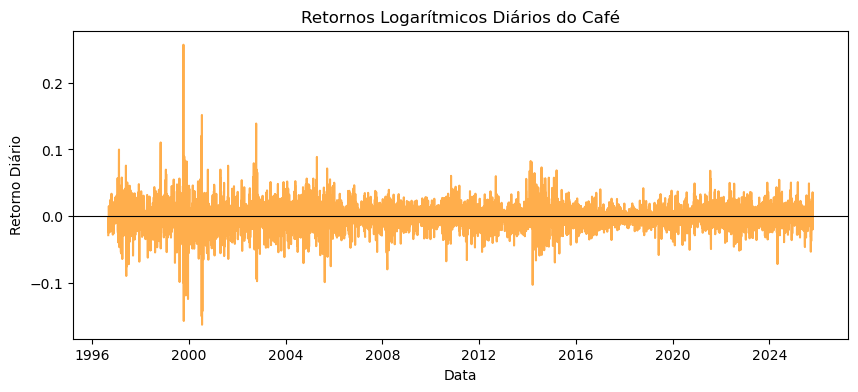

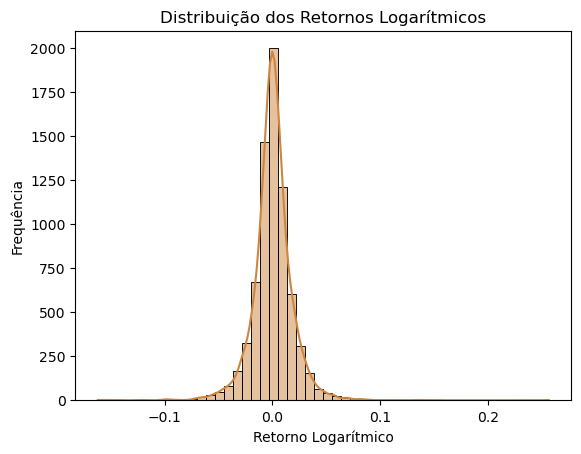

=== Medidas de Forma dos Retornos ===
Curtose (Kurtosis): 11.6924


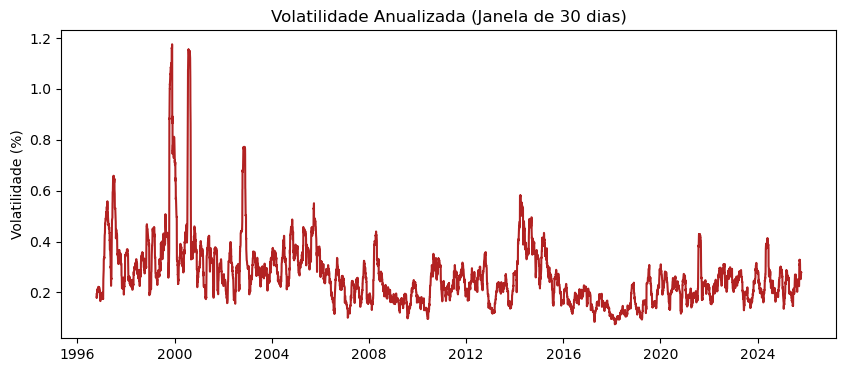


Resumo dos Retornos Logarítmicos:
                       0
Média           0.000401
Desvio-Padrão   0.018661
Assimetria      0.143039
Curtose        11.692431
Min            -0.162006
Max             0.256636


In [3]:
# Ler o arquivo Excel
df = pd.read_excel('Preços café.xls')
df.columns = ['Data', 'Preco']
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
df = df.sort_values('Data').set_index('Data')

# Visualizar início e fim da série
print(df.head())
print(df.tail())

# Plotar a série
plt.figure(figsize=(10,4))
plt.plot(df['Preco'], color='saddlebrown')
plt.title('Preço do Café ao Longo do Tempo')
plt.ylabel('Preço (R$)')
plt.xlabel('Data')
plt.grid(True)
plt.show()

# Estatísticas básicas
print("=== Estatísticas Descritivas ===")
print(df['Preco'].describe().to_string())

# Retornos logarítmicos
df['Retorno_Log'] = np.log(df['Preco'] / df['Preco'].shift(1))
print("\n=== Estatísticas dos Retornos Logarítmicos ===")
print(df['Retorno_Log'].describe().to_string())

# Plot dos retornos
plt.figure(figsize=(10,4))
plt.plot(df['Retorno_Log'], color='darkorange', alpha=0.7)
plt.title('Retornos Logarítmicos Diários do Café')
plt.ylabel('Retorno Diário')
plt.xlabel('Data')
plt.axhline(0, color='black', lw=0.8)
plt.show()

sns.histplot(df['Retorno_Log'].dropna(), bins=50, kde=True, color='peru')
plt.title('Distribuição dos Retornos Logarítmicos')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frequência')
plt.show()

print("=== Medidas de Forma dos Retornos ===")
print(f"Curtose (Kurtosis): {kurtosis(df['Retorno_Log'].dropna(), fisher=True):.4f}")

# Volatilidade móvel (desvio-padrão de 30 dias)
df['Volatilidade_30d'] = df['Retorno_Log'].rolling(window=30).std() * np.sqrt(252)  # anualizada
plt.figure(figsize=(10,4))
plt.plot(df['Volatilidade_30d'], color='firebrick')
plt.title('Volatilidade Anualizada (Janela de 30 dias)')
plt.ylabel('Volatilidade (%)')
plt.show()

summary = pd.DataFrame({
    'Média': [df['Retorno_Log'].mean()],
    'Desvio-Padrão': [df['Retorno_Log'].std()],
    'Assimetria': [skew(df['Retorno_Log'].dropna())],
    'Curtose': [kurtosis(df['Retorno_Log'].dropna(), fisher=True)],
    'Min': [df['Retorno_Log'].min()],
    'Max': [df['Retorno_Log'].max()]
})
print("\nResumo dos Retornos Logarítmicos:")
print(summary.T)

In [4]:
# ==============================================================
# 2. FUNÇÃO DE VEROSSIMILHANÇA (μ FIXO = 0)
# ==============================================================

retornos = df['Retorno_Log'].dropna().values

def merton_log_likelihood(params, data):
    sigma, lamb, mu_j, sigma_j = params
    mu = 0  # FIXO
    
    if sigma <= 0 or lamb < 0 or sigma_j <= 0:
        return 1e10
    
    dt = 1
    likelihood = 0
    
    for k in range(10):
        p_k = (np.exp(-lamb * dt) * (lamb * dt)**k) / math.factorial(k)
        
        mu_total = (mu - lamb * mu_j - 0.5 * sigma**2) * dt + k * mu_j
        var_total = (sigma**2 * dt) + k * (sigma_j**2)
        
        likelihood += p_k * norm.pdf(data, loc=mu_total, scale=np.sqrt(var_total))
    
    likelihood = np.maximum(likelihood, 1e-12)
    
    return -np.sum(np.log(likelihood))

# ==============================================================
# 3. ESTIMAÇÃO VIA MLE
# ==============================================================

initial_guess = [retornos.std(), 0.05, 0.0, retornos.std()*2]

result = minimize(
    merton_log_likelihood,
    initial_guess,
    args=(retornos,),
    method='L-BFGS-B',
    bounds=[
        (1e-6, None),  # sigma
        (1e-6, None),  # lambda (removi limite superior 1)
        (None, None),  # mu_j
        (1e-6, None)   # sigma_j
    ]
)

sigma_mle, lamb_mle, muj_mle, sigmaj_mle = result.x

# ==============================================================
# 4. RESULTADOS
# ==============================================================

print("---- Parâmetros Estimados via MLE (μ = 0 fixo) ----")
print(f"μ (drift): 0 (fixado)")
print(f"σ (volatilidade contínua): {sigma_mle:.6f}")
print(f"λ (intensidade de saltos): {lamb_mle:.6f}")
print(f"μ_j (média do salto): {muj_mle:.6f}")
print(f"σ_j (desvio do salto): {sigmaj_mle:.6f}")

---- Parâmetros Estimados via MLE (μ = 0 fixo) ----
μ (drift): 0 (fixado)
σ (volatilidade contínua): 0.008396
λ (intensidade de saltos): 0.642432
μ_j (média do salto): -0.000393
σ_j (desvio do salto): 0.019949


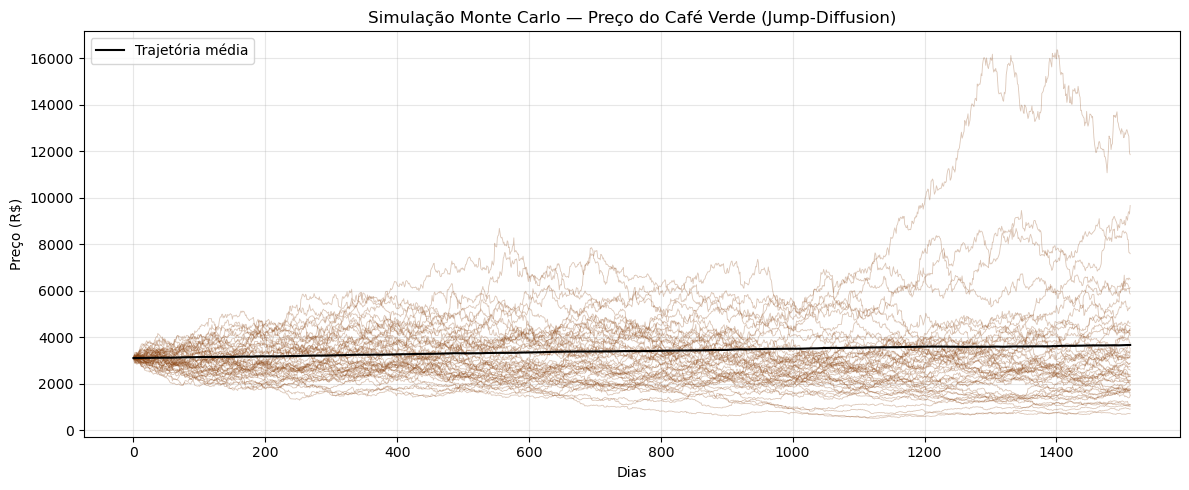


Parâmetros utilizados (escala diária):
  S0     = 3100.00
  σ      = 0.008396
  λ      = 0.642432
  μⱼ     = -0.000393
  σⱼ     = 0.019949
  Drift ajustado (μ - λμⱼ) = 0.000253

--- Preço de Venda (PERT) ---
  E(x) teórico = R$ 40.00
  E(x) simulado= R$ 40.0000
  Mín simulado = R$ 38.0338
  Máx simulado = R$ 41.9666


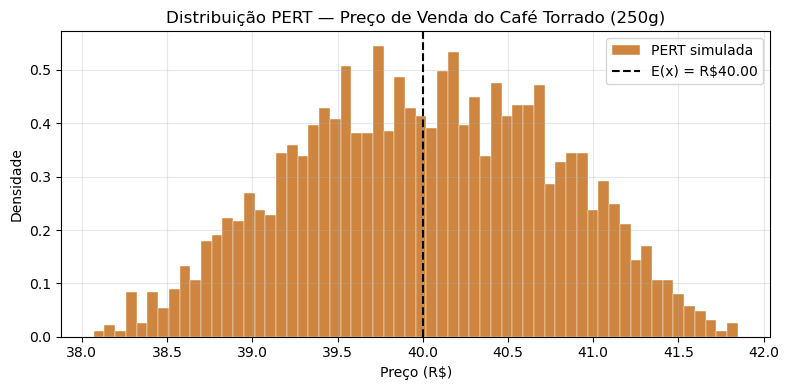


--- Quantidade Vendida (PERT crescente) ---
  Período  1: moda=3.0 | E(x) teórico=3.00 | E(x) simulado=2.9962
  Período 72: moda=13.0 | E(x) teórico=13.00 | E(x) simulado=13.0071


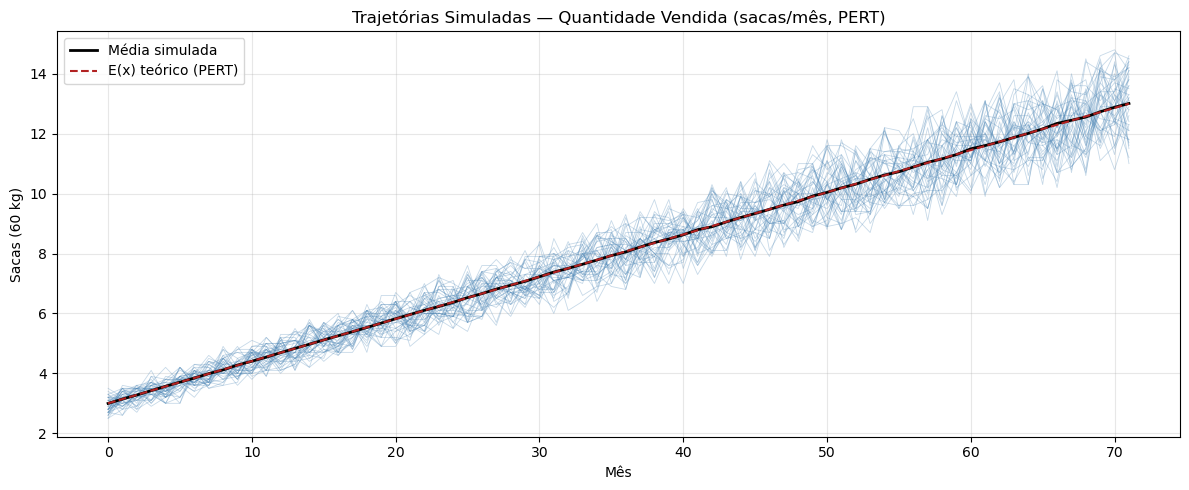

In [5]:
"""
=============================================================
MODELAGEM DAS 3 DISTRIBUIÇÕES - SIMULAÇÃO MONTE CARLO CAFÉ
=============================================================
Este módulo é um complemento ao notebook Simulação_Monte_Carlo.ipynb.
Assume que os parâmetros MLE (mu_mle, sigma_mle, lamb_mle, muj_mle,
sigmaj_mle) e o preço inicial (S0) já foram estimados nas células
anteriores do notebook.
 
CORREÇÕES aplicadas em relação ao código original:
  1. Preço de venda: triangular → PERT (Beta redimensionada)
  2. Quantidade vendida: truncnorm → PERT com limites ±20% da moda
  3. Adicionada simulação jump-diffusion que gera 'resultados'
  4. dt mantido em escala diária (consistente com MLE onde dt=1)
=============================================================
"""

 
# =============================================================
# FUNÇÃO AUXILIAR: DISTRIBUIÇÃO PERT
# =============================================================
 
def pert_rvs(a, m, b, size):
    """
    Amostra da distribuição PERT via Beta redimensionada.
 
    Parâmetros
    ----------
    a : float ou array — limite inferior
    m : float ou array — moda (valor mais provável)
    b : float ou array — limite superior
    size : int — número de amostras
 
    Retorna
    -------
    np.ndarray de shape (size,)
 
    Fórmula do valor esperado: E(x) = (a + 4m + b) / 6
    Shape parameters da Beta:
        alpha = 1 + 4*(m - a)/(b - a)
        beta  = 1 + 4*(b - m)/(b - a)
    """
    a, m, b = np.asarray(a, float), np.asarray(m, float), np.asarray(b, float)
    if np.any(b <= a):
        raise ValueError("Limite superior 'b' deve ser maior que 'a'.")
    if np.any((m < a) | (m > b)):
        raise ValueError("Moda 'm' deve estar entre 'a' e 'b'.")
 
    alpha = 1 + 4 * (m - a) / (b - a)
    beta  = 1 + 4 * (b - m) / (b - a)
 
    samples = beta_dist.rvs(alpha, beta, size=size)
    return a + (b - a) * samples
 
 
# =============================================================
# DISTRIBUIÇÃO 1: CAFÉ VERDE — JUMP-DIFFUSION (Merton, 1976)
# =============================================================
# NOTA: Esta seção deve ser executada APÓS a estimação MLE
# do notebook original, que gera:
#   sigma_mle, lamb_mle, muj_mle, sigmaj_mle
#
# Ajuste o S0 e n_simulacoes conforme seu contexto.
# =============================================================
 
def simular_jump_diffusion(S0, mu, sigma, lamb, mu_j, sigma_j,
                           n_dias, n_simulacoes, dt=1):
    """
    Simula trajetórias de preço pelo modelo Jump-Diffusion de Merton.
 
    Equação discreta:
        S[t+1] = S[t] * exp( drift_ajustado + sigma*sqrt(dt)*Z + J_t )
 
    Onde:
        drift_ajustado = (mu - lamb*mu_j - 0.5*sigma²) * dt
        J_t = soma de N_t saltos ~ Normal(mu_j, sigma_j)
        N_t ~ Poisson(lamb * dt)
 
    O ajuste (mu - lamb*mu_j) evita dupla contagem do impacto médio
    dos saltos, conforme Merton (1976) e descrito no texto.
 
    Parâmetros em escala DIÁRIA (consistente com MLE onde dt=1).
 
    Parâmetros
    ----------
    S0            : float — preço inicial do café verde
    mu            : float — drift diário estimado via MLE
    sigma         : float — volatilidade contínua diária
    lamb          : float — intensidade de saltos (saltos/dia)
    mu_j          : float — média do tamanho dos saltos (log)
    sigma_j       : float — desvio-padrão do tamanho dos saltos
    n_dias        : int   — número de dias a simular (ex: 6*252=1512)
    n_simulacoes  : int   — número de trajetórias Monte Carlo
    dt            : float — passo de tempo (1 = diário, padrão)
 
    Retorna
    -------
    resultados : np.ndarray de shape (n_simulacoes, n_dias + 1)
    """
    resultados = np.zeros((n_simulacoes, n_dias + 1))
    resultados[:, 0] = S0
 
    # Drift ajustado: remove a parcela média dos saltos para
    # evitar dupla contagem (Merton, 1976)
    drift_ajustado = (mu - lamb * mu_j - 0.5 * sigma**2) * dt
 
    for t in range(n_dias):
        # Componente browniano contínuo
        Z = np.random.standard_normal(n_simulacoes)
        difusao = sigma * np.sqrt(dt) * Z
 
        # Componente de saltos (Poisson + Normal)
        N_t = poisson.rvs(lamb * dt, size=n_simulacoes)
        J_t = np.zeros(n_simulacoes)
 
        idx_saltos = np.where(N_t > 0)[0]
        for i in idx_saltos:
            J_t[i] = np.sum(np.random.normal(mu_j, sigma_j, N_t[i]))
 
        log_retorno = drift_ajustado + difusao + J_t
        resultados[:, t + 1] = resultados[:, t] * np.exp(log_retorno)
 
    return resultados
 
 
# --- EXECUÇÃO ---
 
n_anos       = 6
n_dias_sim   = n_anos * 252          # 1512 dias úteis
n_simulacoes = 3000
 
# S0 = último preço observado da série (ajuste conforme seu df)
S0 = 3100
 
resultados = simular_jump_diffusion(
    S0          = S0,
    mu          = 0,
    sigma       = sigma_mle,
    lamb        = lamb_mle,
    mu_j        = muj_mle,
    sigma_j     = sigmaj_mle,
    n_dias      = n_dias_sim,
    n_simulacoes= n_simulacoes
)
 
# Visualização de trajetórias
plt.figure(figsize=(12, 5))
for i in range(50):
    plt.plot(resultados[i], alpha=0.3, linewidth=0.6, color='saddlebrown')
plt.plot(resultados.mean(axis=0), color='black', linewidth=1.5,
         label='Trajetória média')
plt.title('Simulação Monte Carlo — Preço do Café Verde (Jump-Diffusion)')
plt.xlabel('Dias')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print(f"\nParâmetros utilizados (escala diária):")
print(f"  S0     = {S0:.2f}")
print(f"  σ      = {sigma_mle:.6f}")
print(f"  λ      = {lamb_mle:.6f}")
print(f"  μⱼ     = {muj_mle:.6f}")
print(f"  σⱼ     = {sigmaj_mle:.6f}")
print(f"  Drift ajustado (μ - λμⱼ) = {0 - lamb_mle*muj_mle:.6f}")
 
dias_por_mes = 21
n_meses = n_dias_sim // dias_por_mes

# =============================================================
# DISTRIBUIÇÃO 2: PREÇO DO CAFÉ TORRADO — PERT
# =============================================================
# CORREÇÃO: código original usava triangular. Substituído por PERT
# conforme metodologia descrita no texto.
#
# Parâmetros: a=38 (mínimo), m=40 (moda), b=42 (máximo)
# E(x) = (38 + 4*40 + 42) / 6 = 40.00
# =============================================================
 
a_venda = 38.0
m_venda = 40.0
b_venda = 42.0
 
# Gerado para cada simulação e cada mês
preco_venda = np.column_stack([
    pert_rvs(a_venda, m_venda, b_venda, size=n_simulacoes)
    for _ in range(n_meses)
])
 
# Valor esperado teórico
E_preco_venda = (a_venda + 4 * m_venda + b_venda) / 6
print(f"\n--- Preço de Venda (PERT) ---")
print(f"  E(x) teórico = R$ {E_preco_venda:.2f}")
print(f"  E(x) simulado= R$ {preco_venda.mean():.4f}")
print(f"  Mín simulado = R$ {preco_venda.min():.4f}")
print(f"  Máx simulado = R$ {preco_venda.max():.4f}")
 
# Histograma
plt.figure(figsize=(8, 4))
plt.hist(preco_venda[:, 0], bins=60, color='peru', edgecolor='white',
         linewidth=0.3, density=True, label='PERT simulada')
plt.axvline(E_preco_venda, color='black', linestyle='--',
            label=f'E(x) = R${E_preco_venda:.2f}')
plt.title('Distribuição PERT — Preço de Venda do Café Torrado (250g)')
plt.xlabel('Preço (R$)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
 
# =============================================================
# DISTRIBUIÇÃO 3: QUANTIDADE VENDIDA — PERT COM CRESCIMENTO
# =============================================================
# CORREÇÃO: código original usava truncnorm. Substituído por PERT
# conforme metodologia do texto.
#
# Crescimento: 3 sacas/mês (início) → 13 sacas/mês (6 anos)
# Variabilidade: ±20% da moda em cada período
#   a_t = 0.8 * moda_t
#   b_t = 1.2 * moda_t
# =============================================================
 
moda_inicial = 3.0
moda_final   = 13.0
 
moda_periodo = np.linspace(moda_inicial, moda_final, n_meses)
a_periodo    = 0.8 * moda_periodo   # limite inferior (-20%)
b_periodo    = 1.2 * moda_periodo   # limite superior (+20%)
 
quantidade = np.zeros((n_simulacoes, n_meses))
 
for t in range(n_meses):
    quantidade[:, t] = pert_rvs(
        a=a_periodo[t],
        m=moda_periodo[t],
        b=b_periodo[t],
        size=n_simulacoes
    )
 
quantidade = np.round(quantidade, 1)
 
# Valor esperado teórico por período: (a + 4m + b) / 6 = m (simétrico)
E_quantidade = (a_periodo + 4 * moda_periodo + b_periodo) / 6
 
print(f"\n--- Quantidade Vendida (PERT crescente) ---")
print(f"  Período  1: moda={moda_periodo[0]:.1f} | "
      f"E(x) teórico={E_quantidade[0]:.2f} | "
      f"E(x) simulado={quantidade[:, 0].mean():.4f}")
print(f"  Período {n_meses:2d}: moda={moda_periodo[-1]:.1f} | "
      f"E(x) teórico={E_quantidade[-1]:.2f} | "
      f"E(x) simulado={quantidade[:, -1].mean():.4f}")
 
# Trajetórias simuladas
plt.figure(figsize=(12, 5))
for i in range(40):
    plt.plot(quantidade[i], alpha=0.3, linewidth=0.6, color='steelblue')
plt.plot(quantidade.mean(axis=0), color='black', linewidth=2,
         label='Média simulada')
plt.plot(E_quantidade, color='firebrick', linewidth=1.5,
         linestyle='--', label='E(x) teórico (PERT)')
plt.title('Trajetórias Simuladas — Quantidade Vendida (sacas/mês, PERT)')
plt.xlabel('Mês')
plt.ylabel('Sacas (60 kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# -----------------------------
# CONFIGURAÇÕES
# -----------------------------
dias_por_mes = 21
arquivo_excel = "Modelagem Cafés Especiais Teste.xlsx"
aba_excel = "Distribuições"
celula_vpl = "C35"
n_sim = 100

# DEFINA AQUI AS LINHAS CONTÍGUAS QUE VOCÊ RESERVOU NO EXCEL
# (Usaremos a coluna D como início, pois o seu modelo começa na coluna D)
range_precos_cafe = "D50"
range_quantidades = "D51"
range_precos_venda = "D52"

# -----------------------------
# CONECTAR AO EXCEL
# -----------------------------
wb = xw.Book(arquivo_excel)
sheet = wb.sheets[aba_excel]
app = wb.app
app.screen_updating = False
app.calculation = "manual"
app.display_alerts = False
app.enable_events = False

# -----------------------------
# PREPARAÇÃO DOS DADOS
# -----------------------------
traj = resultados[:n_sim]
n_sim_real = traj.shape[0]
n_dias = traj.shape[1]
n_meses = n_dias // dias_por_mes
traj = traj[:, : n_meses * dias_por_mes]

precos_mensais_all = traj.reshape(n_sim_real, n_meses, dias_por_mes).mean(
    axis=2
)
preco_medio_sim = precos_mensais_all.mean(axis=1)

preco_venda = np.column_stack(
    [pert_rvs(38.0, 40.0, 42.0, size=n_sim_real) for _ in range(n_meses)]
)

moda_periodo = np.linspace(3, 13, n_meses)
quantidade = np.zeros((n_sim_real, n_meses))
for t in range(n_meses):
    quantidade[:, t] = pert_rvs(
        a=0.8 * moda_periodo[t],
        m=moda_periodo[t],
        b=1.2 * moda_periodo[t],
        size=n_sim_real,
    )
quantidade = np.round(quantidade, 1)

# -----------------------------
# MONTE CARLO OTIMIZADO
# -----------------------------
vpl_resultados = []

for i in tqdm(range(n_sim_real), desc="Simulações Monte Carlo"):
    # Escreve todos os meses de uma vez horizontalmente (Apenas 3 chamadas COM)
    sheet.range(range_precos_cafe).value = precos_mensais_all[i, :]
    sheet.range(range_quantidades).value = quantidade[i, :]
    sheet.range(range_precos_venda).value = preco_venda[i, :]

    # Força o recálculo do Excel após preencher a linha toda
    wb.app.calculate()

    # Leitura do resultado
    vpl = sheet[celula_vpl].value
    if vpl is not None:
        vpl_resultados.append(float(vpl))

# -----------------------------
# FINALIZAR E RESTAURAR EXCEL
# -----------------------------
app.calculation = "automatic"
app.screen_updating = True
app.enable_events = True
vpl_resultados = np.array(vpl_resultados)

# -----------------------------
# RESULTADOS
# -----------------------------
print("VPL médio:", np.mean(vpl_resultados))
print("Probabilidade VPL negativo:", np.mean(vpl_resultados < 0))
print("Percentil 5%:", np.percentile(vpl_resultados, 5))
print("Percentil 95%:", np.percentile(vpl_resultados, 95))

tabela_vpl = pd.DataFrame(
    {
        "Simulação": np.arange(1, len(vpl_resultados) + 1),
        "VPL": vpl_resultados,
        "Preço médio do café": preco_medio_sim[: len(vpl_resultados)],
    }
)
print("\n=== Alguns VPLs simulados ===")
print(tabela_vpl.head())

Simulações Monte Carlo: 100%|██████████| 100/100 [00:07<00:00, 13.50it/s]

VPL médio: 118054.128012
Probabilidade VPL negativo: 0.3
Percentil 5%: -837186.721515
Percentil 95%: 785926.01871

=== Alguns VPLs simulados ===
   Simulação          VPL  Preço médio do café
0          1  574270.4774          2181.273582
1          2   46029.2134          3432.604328
2          3  279269.5808          2853.370633
3          4  203882.3406          3081.580470
4          5  960354.7603          1231.574244



=== 1. DISTRIBUIÇÃO DO VPL ===


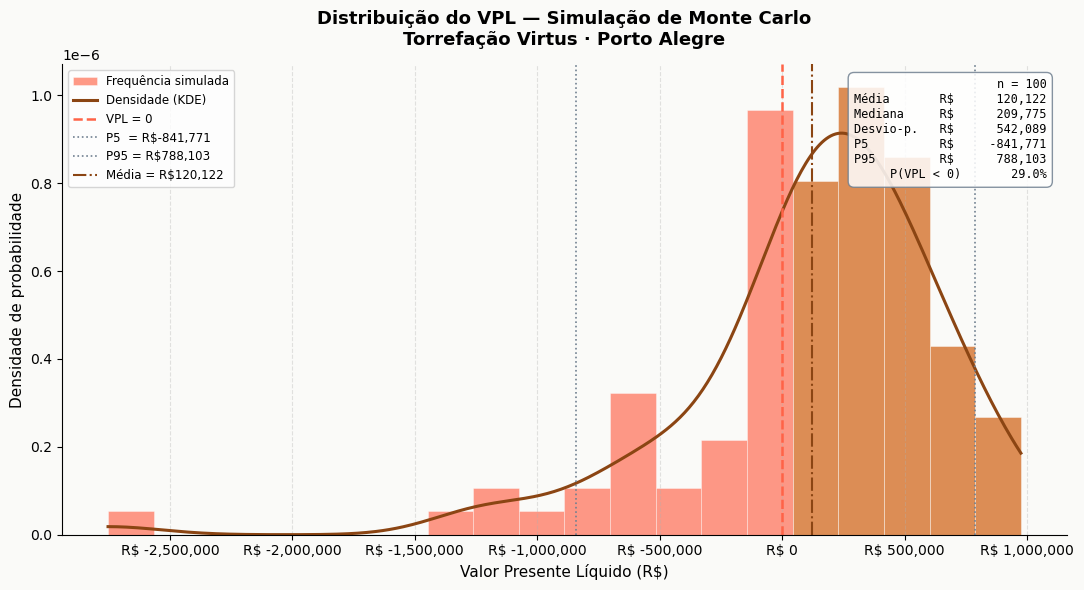


[Figura salva] distribuicao_vpl.png

=== 2. ANÁLISE DE SENSIBILIDADE (re-simulações ±10%) ===
  Sensibilidade: Preço café torrado  -10%...


com_error: (-2146827864, 'OLE error 0x800a01a8', None, None)

In [12]:
# Paleta de cores consistente com o estilo do TCC
COR_PRIMARIA   = "#8B4513"   # marrom café
COR_SECUNDARIA = "#D2691E"
COR_DESTAQUE   = "#FF6347"   # vermelho para negativo / alerta
COR_POSITIVO   = "#2E8B57"
COR_NEUTRO     = "#708090"
FUNDO          = "#FAFAF8"


# =============================================================================
# BLOCO 1 — DISTRIBUIÇÃO DE PROBABILIDADE DO VPL
# =============================================================================

def plot_distribuicao_vpl(vpl_resultados: np.ndarray) -> None:
    """
    Histograma + KDE do VPL simulado, com linha de corte em zero,
    estatísticas descritivas e probabilidade de inviabilidade.
    """
    fig, ax = plt.subplots(figsize=(11, 6), facecolor=FUNDO)
    ax.set_facecolor(FUNDO)

    # --- Histograma ---
    n_bins = min(60, max(20, len(vpl_resultados) // 10))
    counts, bins, patches = ax.hist(
        vpl_resultados, bins=n_bins,
        color=COR_SECUNDARIA, edgecolor="white", linewidth=0.4,
        density=True, alpha=0.75, label="Frequência simulada"
    )

    # Colorir barras negativas de vermelho
    for patch, left in zip(patches, bins[:-1]):
        if left < 0:
            patch.set_facecolor(COR_DESTAQUE)
            patch.set_alpha(0.65)

    # --- KDE suavizado ---
    kde = stats.gaussian_kde(vpl_resultados, bw_method="scott")
    x_range = np.linspace(vpl_resultados.min(), vpl_resultados.max(), 400)
    ax.plot(x_range, kde(x_range), color=COR_PRIMARIA, linewidth=2.2, label="Densidade (KDE)")

    # --- Linha zero ---
    ax.axvline(0, color=COR_DESTAQUE, linewidth=1.8, linestyle="--", label="VPL = 0")

    # --- Linhas de percentil ---
    p5  = np.percentile(vpl_resultados, 5)
    p95 = np.percentile(vpl_resultados, 95)
    ax.axvline(p5,  color=COR_NEUTRO, linewidth=1.2, linestyle=":", label=f"P5  = R${p5:,.0f}")
    ax.axvline(p95, color=COR_NEUTRO, linewidth=1.2, linestyle=":",  label=f"P95 = R${p95:,.0f}")

    # --- Média ---
    media = np.mean(vpl_resultados)
    ax.axvline(media, color=COR_PRIMARIA, linewidth=1.5, linestyle="-.",
               label=f"Média = R${media:,.0f}")

    # --- Box de estatísticas ---
    prob_neg = np.mean(vpl_resultados < 0)
    texto = (
        f"n = {len(vpl_resultados):,}\n"
        f"Média       R$ {media:>12,.0f}\n"
        f"Mediana     R$ {np.median(vpl_resultados):>12,.0f}\n"
        f"Desvio-p.   R$ {np.std(vpl_resultados):>12,.0f}\n"
        f"P5          R$ {p5:>12,.0f}\n"
        f"P95         R$ {p95:>12,.0f}\n"
        f"P(VPL < 0)       {prob_neg:.1%}"
    )
    ax.text(
        0.98, 0.97, texto,
        transform=ax.transAxes,
        fontsize=8.5, verticalalignment="top", horizontalalignment="right",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor=COR_NEUTRO, alpha=0.85)
    )

    # --- Formatação ---
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")
    )
    ax.set_xlabel("Valor Presente Líquido (R$)", fontsize=11)
    ax.set_ylabel("Densidade de probabilidade", fontsize=11)
    ax.set_title(
        "Distribuição do VPL — Simulação de Monte Carlo\n"
        "Torrefação Virtus · Porto Alegre",
        fontsize=13, fontweight="bold", pad=14
    )
    ax.legend(fontsize=8.5, loc="upper left")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("distribuicao_vpl.png", dpi=180, bbox_inches="tight",
                facecolor=FUNDO)
    plt.show()
    print(f"\n[Figura salva] distribuicao_vpl.png")


# =============================================================================
# BLOCO 2 — ANÁLISE DE SENSIBILIDADE ESTOCÁSTICA
# =============================================================================

def rodar_simulacao_sensibilidade(
    precos_mensais_all_base: np.ndarray,
    preco_venda_base: np.ndarray,
    quantidade_base: np.ndarray,
    variacao: float,
    variavel: str,
    sheet, wb, celula_vpl: str,
    dias_por_mes: int = 21
) -> np.ndarray:
    """
    Re-executa o loop Monte Carlo aplicando ±variacao% em UMA variável.
    variavel: 'cafe_verde' | 'cafe_torrado' | 'quantidade'
    Retorna array de VPLs.
    """
    n_sim = precos_mensais_all_base.shape[0]
    n_meses = precos_mensais_all_base.shape[1]
    fator = 1.0 + variacao

    vpl_sens = []
    for i in range(n_sim):
        # Definir valores conforme variável perturbada
        pv_cafe  = precos_mensais_all_base[i] * (fator if variavel == "cafe_verde"   else 1.0)
        pv_torr  = preco_venda_base[i]        * (fator if variavel == "cafe_torrado" else 1.0)
        qt       = quantidade_base[i]         * (fator if variavel == "quantidade"   else 1.0)

        for m in range(n_meses):
            col = 4 + m * 4
            sheet.cells(2, col).value = pv_cafe[m]
            sheet.cells(5, col).value = qt[m]
            sheet.cells(6, col).value = pv_torr[m]

        wb.app.calculate()
        vpl = sheet[celula_vpl].value
        if vpl is not None:
            vpl_sens.append(float(vpl))

    return np.array(vpl_sens)


def analise_sensibilidade_estocastica(
    vpl_base: np.ndarray,
    precos_mensais_all: np.ndarray,
    preco_venda: np.ndarray,
    quantidade: np.ndarray,
    sheet, wb, celula_vpl: str
) -> pd.DataFrame:
    """
    Varia cada variável-chave em ±10%, recalcula o VPL médio e
    constrói o gráfico tornado.
    """
    variacoes = [-0.10, +0.10]
    variaveis = {
        "Preço café torrado": "cafe_torrado",
        "Preço café verde":   "cafe_verde",
        "Volume vendido":     "quantidade",
    }

    resultados = {}
    for label, chave in variaveis.items():
        resultados[label] = {}
        for var in variacoes:
            print(f"  Sensibilidade: {label}  {'+' if var>0 else ''}{var:.0%}...")
            vpl_s = rodar_simulacao_sensibilidade(
                precos_mensais_all, preco_venda, quantidade,
                var, chave, sheet, wb, celula_vpl
            )
            resultados[label][var] = np.mean(vpl_s)

    media_base = np.mean(vpl_base)

    # Montar DataFrame
    linhas = []
    for label, res in resultados.items():
        vpl_m10 = res[-0.10]
        vpl_p10 = res[+0.10]
        imp_p10 = (vpl_p10 - media_base) / abs(media_base) * 100
        imp_m10 = (vpl_m10 - media_base) / abs(media_base) * 100
        linhas.append({
            "Variável":         label,
            "VPL Base (R$)":    media_base,
            "VPL -10% (R$)":    vpl_m10,
            "VPL +10% (R$)":    vpl_p10,
            "Impacto +10%":     imp_p10,
            "Impacto -10%":     imp_m10,
        })
    df = pd.DataFrame(linhas).sort_values(
        "Impacto +10%", key=abs, ascending=False
    ).reset_index(drop=True)

    # --- Gráfico Tornado ---
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=FUNDO)
    ax.set_facecolor(FUNDO)

    y_pos = np.arange(len(df))
    for idx, row in df.iterrows():
        low  = min(row["VPL -10% (R$)"], row["VPL +10% (R$)"])
        high = max(row["VPL -10% (R$)"], row["VPL +10% (R$)"])
        ax.barh(idx, high - low, left=low, height=0.5,
                color=COR_SECUNDARIA, alpha=0.8)
        ax.barh(idx, row["VPL +10% (R$)"] - media_base,
                left=media_base, height=0.5,
                color=COR_POSITIVO, alpha=0.75)
        ax.barh(idx, row["VPL -10% (R$)"] - media_base,
                left=media_base, height=0.5,
                color=COR_DESTAQUE, alpha=0.75)

    ax.axvline(media_base, color=COR_PRIMARIA, linewidth=1.8,
               linestyle="--", label=f"VPL base médio = R${media_base:,.0f}")
    ax.axvline(0, color=COR_DESTAQUE, linewidth=1.2,
               linestyle=":", alpha=0.6, label="VPL = 0")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["Variável"], fontsize=10)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")
    )
    ax.set_xlabel("VPL médio simulado (R$)", fontsize=10)
    ax.set_title(
        "Análise de Sensibilidade — Variação de ±10% (Estocástica)\n"
        "Torrefação Virtus · Porto Alegre",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.legend(fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("sensibilidade_tornado.png", dpi=180, bbox_inches="tight",
                facecolor=FUNDO)
    plt.show()
    print("[Figura salva] sensibilidade_tornado.png")

    return df


# =============================================================================
# BLOCO 3 — PONTO DE EQUILÍBRIO: VOLUME VENDIDO MÊS A MÊS
# =============================================================================

def calcular_ponto_equilibrio_mensal(
    precos_mensais_all: np.ndarray,
    preco_venda: np.ndarray,
    moda_periodo: np.ndarray,
    sheet, wb, celula_vpl: str,
    n_busca: int = 30,
    tol_rs: float = 500.0
) -> pd.DataFrame:
    """
    Para cada mês, encontra por busca binária a quantidade mínima (em sacas)
    que torna o VPL ≥ 0, mantendo as demais simulações no valor esperado PERT.

    Usa a média das simulações para preço do café verde e preço do torrado,
    isolando o efeito do volume.

    Retorna DataFrame com mês e quantidade de equilíbrio.
    """
    n_meses = precos_mensais_all.shape[1]
    pv_cafe_medio  = precos_mensais_all.mean(axis=0)   # (n_meses,)
    pv_torr_medio  = preco_venda.mean(axis=0)           # (n_meses,)

    # Função auxiliar: escreve um vetor de quantidades no Excel e retorna VPL
    def _vpl_para_qtd(qtd_vetor: np.ndarray) -> float:
        for m in range(n_meses):
            col = 4 + m * 4
            sheet.cells(2, col).value = pv_cafe_medio[m]
            sheet.cells(5, col).value = float(qtd_vetor[m])
            sheet.cells(6, col).value = pv_torr_medio[m]
        wb.app.calculate()
        v = sheet[celula_vpl].value
        return float(v) if v is not None else np.nan

    # Para cada mês, busca binária na quantidade DAQUELE mês
    # (todos os outros meses ficam na moda PERT)
    qtd_equilibrio = []
    qtd_base = moda_periodo.copy()   # ponto de partida = moda esperada

    for mes in range(n_meses):
        lo, hi = 0.5, 50.0   # limites razoáveis em sacas

        # Verificar se já é viável na moda — se sim, equilíbrio <= moda
        qtd_test = qtd_base.copy()

        # Busca binária
        for _ in range(n_busca):
            mid = (lo + hi) / 2.0
            qtd_test[mes] = mid
            vpl_mid = _vpl_para_qtd(qtd_test)

            if np.isnan(vpl_mid):
                break
            if vpl_mid >= 0:
                hi = mid
            else:
                lo = mid

            if (hi - lo) * 1000 < tol_rs:   # convergência em R$
                break

        qtd_equilibrio.append(round((lo + hi) / 2, 2))

    df_eq = pd.DataFrame({
        "Mês":                   np.arange(1, n_meses + 1),
        "Qtd. moda PERT (scs)":  np.round(moda_periodo, 2),
        "Qtd. equilíbrio (scs)": qtd_equilibrio,
    })
    df_eq["Folga (scs)"] = (
        df_eq["Qtd. moda PERT (scs)"] - df_eq["Qtd. equilíbrio (scs)"]
    ).round(2)
    df_eq["Status"] = df_eq["Folga (scs)"].apply(
        lambda x: "✓ Viável" if x >= 0 else "✗ Risco"
    )

    # --- Gráfico ---
    fig, ax = plt.subplots(figsize=(13, 6), facecolor=FUNDO)
    ax.set_facecolor(FUNDO)

    meses = df_eq["Mês"].values
    ax.fill_between(meses, df_eq["Qtd. equilíbrio (scs)"],
                    df_eq["Qtd. moda PERT (scs)"],
                    where=df_eq["Qtd. moda PERT (scs)"] >= df_eq["Qtd. equilíbrio (scs)"],
                    alpha=0.18, color=COR_POSITIVO, label="Margem de segurança")
    ax.fill_between(meses, df_eq["Qtd. equilíbrio (scs)"],
                    df_eq["Qtd. moda PERT (scs)"],
                    where=df_eq["Qtd. moda PERT (scs)"] < df_eq["Qtd. equilíbrio (scs)"],
                    alpha=0.18, color=COR_DESTAQUE, label="Zona de risco")

    ax.plot(meses, df_eq["Qtd. equilíbrio (scs)"],
            color=COR_DESTAQUE, linewidth=2.2, marker="o", markersize=3.5,
            label="Ponto de equilíbrio (VPL = 0)")
    ax.plot(meses, df_eq["Qtd. moda PERT (scs)"],
            color=COR_POSITIVO, linewidth=2.2, linestyle="--", marker="s", markersize=3.5,
            label="Quantidade esperada PERT (moda)")

    # Destacar transição de nano → micro torrefação (mês ~12)
    ax.axvline(12, color=COR_NEUTRO, linewidth=1.2, linestyle=":",
               alpha=0.7, label="Transição nano→micro (ref.)")

    ax.set_xlabel("Mês de operação", fontsize=11)
    ax.set_ylabel("Sacas de 60 kg / mês", fontsize=11)
    ax.set_title(
        "Ponto de Equilíbrio — Volume Mínimo para VPL ≥ 0\n"
        "Torrefação Virtus · Porto Alegre",
        fontsize=13, fontweight="bold", pad=14
    )
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(6))

    plt.tight_layout()
    plt.savefig("ponto_equilibrio_mensal.png", dpi=180, bbox_inches="tight",
                facecolor=FUNDO)
    plt.show()
    print("[Figura salva] ponto_equilibrio_mensal.png")

    return df_eq


# =============================================================================
# EXECUÇÃO PRINCIPAL (colar logo após o bloco de resultados existente)
# =============================================================================
if __name__ == "__main__":

    # ── 1. Distribuição do VPL ─────────────────────────────────────────────
    print("\n=== 1. DISTRIBUIÇÃO DO VPL ===")
    plot_distribuicao_vpl(vpl_resultados)

    # ── 2. Análise de sensibilidade ────────────────────────────────────────
    print("\n=== 2. ANÁLISE DE SENSIBILIDADE (re-simulações ±10%) ===")
    # Desativa atualização de tela para performance
    app.screen_updating = False
    app.calculation = "manual"

    df_sens = analise_sensibilidade_estocastica(
        vpl_base          = vpl_resultados,
        precos_mensais_all= precos_mensais_all,
        preco_venda       = preco_venda,
        quantidade        = quantidade,
        sheet             = sheet,
        wb                = wb,
        celula_vpl        = celula_vpl
    )
    print("\nTabela de sensibilidade (médias simuladas):")
    print(df_sens.to_string(index=False, float_format=lambda x: f"R$ {x:,.0f}" if abs(x) > 10 else f"{x:.1f}%"))

    # ── 3. Ponto de equilíbrio ─────────────────────────────────────────────
    print("\n=== 3. PONTO DE EQUILÍBRIO POR VOLUME ===")
    df_eq = calcular_ponto_equilibrio_mensal(
        precos_mensais_all = precos_mensais_all,
        preco_venda        = preco_venda,
        moda_periodo       = moda_periodo,   # array já definido no código original
        sheet              = sheet,
        wb                 = wb,
        celula_vpl         = celula_vpl
    )
    print("\nPrimeiros e últimos meses:")
    print(pd.concat([df_eq.head(6), df_eq.tail(6)]).to_string(index=False))

    # Exportar tabelas para Excel auxiliar
    with pd.ExcelWriter("resultados_simulacao.xlsx", engine="openpyxl") as writer:
        tabela_vpl.to_excel(writer, sheet_name="VPLs_simulados",   index=False)
        df_sens.to_excel(   writer, sheet_name="Sensibilidade",     index=False)
        df_eq.to_excel(     writer, sheet_name="Ponto_Equilibrio",  index=False)
    print("\n[Excel] resultados_simulacao.xlsx salvo com 3 abas.")

    # Restaurar Excel
    app.calculation     = "automatic"
    app.screen_updating = True
    app.enable_events   = True